# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 11. Evaluasi Clustering






Nama: Hassan Nashrallah

NIM: 245150200111025

### Import Library

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
data = load_iris()
X = data.data
Y = data.target

### Clustering

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Evaluasi

In [4]:
sil_score = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)
ch_score = calinski_harabasz_score(X, labels)
rand_index = adjusted_rand_score(Y, labels)

print(f'Silhouette Score: {sil_score}')
print(f'Davies-Bouldin Index: {db_index}')
print(f'Calinski-Harabasz Index: {ch_score}')
print(f'Rand Score: {rand_index}')

def purity_score(y_true, y_pred):
  contingency_matrix = np.zeros((np.max(y_pred) + 1, np.max(y_true) + 1))
  for i in range(len(y_true)):
    contingency_matrix[y_pred[i]][y_true[i]] += 1
  return np.sum(np.amax(contingency_matrix, axis=1)) / np.sum(contingency_matrix)
purity = purity_score(Y, labels)
print(f'Purity: {purity}')

Silhouette Score: 0.551191604619592
Davies-Bouldin Index: 0.6660385791628491
Calinski-Harabasz Index: 561.5937320156642
Rand Score: 0.7163421126838476
Purity: 0.8866666666666667


### Visualisasi Cluster

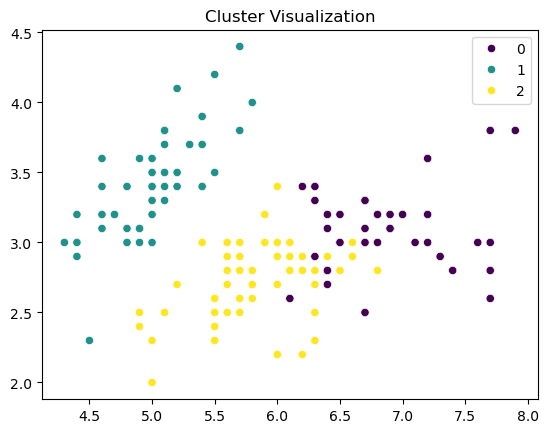

In [5]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis')
plt.title('Cluster Visualization')
plt.show()

## TUGAS
1. Uji evaluasi clustering menggunakan Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, Adjusted Rand Index, dan Purity Score untuk jumlah cluster 2 hingga 6. Catat dan bandingkan hasilnya.
2. Coba dataset Wine (gunakan library sklearn.datasets) dan lakukan evaluasi clustering. Bandingkan hasil evaluasi metriknya.
3. Jelaskan kapan Silhouette Score lebih baik digunakan daripada Davies-Bouldin Index.

### Jawaban

#### 1.

Uji evaluasi clustering untuk jumlah cluster 2 hingga 6. Catat dan bandingkan hasilnya!

In [6]:
results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    results.append({
        "Jumlah Cluster": k,
        "Silhouette Score": silhouette_score(X, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X, labels),
        "Calinski-Harabasz Index": calinski_harabasz_score(X, labels),
        "Adjusted Rand Index": adjusted_rand_score(Y, labels),
        "Purity Score": purity_score(Y, labels)
    })

df_evaluasi = pd.DataFrame(results)
df_evaluasi

c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,Jumlah Cluster,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index,Purity Score
0,2,0.681046,0.404293,513.924546,0.539922,0.666667
1,3,0.551192,0.666039,561.593732,0.716342,0.886667
2,4,0.497643,0.754140,529.529095,0.598328,0.840000
3,5,0.493080,0.819384,495.243414,0.615484,0.906667
4,6,0.367846,0.925770,473.515454,0.455072,0.906667


**Perbandingan hasil:**<br>
Pada cluster 2, nilai Silhouette Score menjadi yang paling tinggi, namun nilai Davies-Bouldin Index menjadi paling rendah. Dalam hal ini, dari sisi pemisahan internal, cluster 2 memiliki struktur yang paling jelas dan rapat. Namun, dengan nilai Adjusted Rand Index dan Purity Score yang belum terlalu tinggi, hasil clustering dengan 2 cluster kemungkinan terlalu sederhana untuk merepresentasikan pola asli pada data.

Pada cluster 3, hasilnya terlihat paling seimbang. Meskipun Silhouette Score turun dibandingkan dengan cluster 2, nilai Calinski-Harabasz Index mencapai angka tertinggi, yaitu 561.593732. Selain itu, Adjusted Rand Index juga paling tinggi, yaitu 0.716342, dengan Purity Score yang cukup baik, yaitu 0.886667. Ini menunjukkan bahwa cluster 3 memiliki keseimbangan yang baik antara struktur internal cluster dan kesesuaian dengan label asli.

Pada cluster 4, performanya cenderung menurun dibanding cluster 3. Silhouette Score lebih rendah, Davies-Bouldin Index lebih tinggi, dan Adjusted Rand Index juga turun. Hal ini berarti penambahan jumlah cluster menjadi 4 belum memberikan peningkatan kualitas yang signifikan. Pada cluster 5, Purity Score mencapai nilai tertinggi, yaitu 0.906667, sama seperti cluster 6. Namun, Silhouette Score dan Davies-Bouldin Index tidak lebih baik dibanding cluster 2 atau 3. Hal ini berarti cluster 5 mungkin lebih baik dalam mencocokkan label asli, namun memiliki struktur cluster yang tidak sekuat cluster 2 atau 3.

Terakhir, pada cluster 6, hasilnya kurang ideal. Walaupun Purity Score tetap tinggi, yaitu 0.906667, nilai Silhouette Score turun cukup jauh menjadi 0.367846, Davies-Bouldin Index menjadi yang paling tinggi, namun Calinski-Harabasz Index menjadi yang paling rendah. Hal ini menunjukkan bahwa cluster 6 kemungkinan terlalu banyak membagi data sehingga cluster menjadi kurang padat dan pemisahannya kurang jelas.


#### 2.

Coba dataset Wine dari `sklearn.datasets`. Lakukan evaluasi clustering dan bandingkan hasilnya~

In [7]:
from sklearn.datasets import load_wine
data = load_wine()
X = data.data
Y = data.target

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

sil_score = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)
ch_score = calinski_harabasz_score(X, labels)
rand_index = adjusted_rand_score(Y, labels)
purity = purity_score(Y, labels)

print(f'Silhouette Score: {sil_score}')
print(f'Davies-Bouldin Index: {db_index}')
print(f'Calinski-Harabasz Index: {ch_score}')
print(f'Rand Score: {rand_index}')
print(f'Purity: {purity}')

Silhouette Score: 0.5595823478987213
Davies-Bouldin Index: 0.5495575974642909
Calinski-Harabasz Index: 497.00487620805814
Rand Score: 0.3517721516862617
Purity: 0.6853932584269663


c:\Users\hassa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Perbandingan hasil:**<br>
Nilai Silhouette pada dataset Wine sedikit lebih tinggi dibandingkan Iris. Hal ini berarti hasil clustering Wine memiliki pemisahan cluster yang sedikit lebih baik, meskipun selisihnya sangat kecil dibandingkan Iris. Kemudian dari segi Davies-Bouldin Index, dataset Wine memiliki nilai yang lebih rendah dibandingkan Iris. Karena semakin rendah Davies-Bouldin Index semakin baik, maka dataset Wine menunjukkan cluster yang lebih padat dan lebih terpisah antarcluster.

Dari metrik Calinski-Harabasz Index, dataset Iris memiliki nilai lebih tinggi dibandingkan Wine. Dalam hal ini, berdasarkan rasio antara pemisahan antarcluster dan kepadatan dalam cluster, struktur cluster Iris lebih baik dari Wine. Kemudian dari metrik Adjusted Rand Index, dataset Iris juga jauh lebih tinggi dibandingkan Wine. Hal ini menunjukkan bahwa hasil clustering K-Means pada dataset Iris jauh lebih sesuai dengan label asli dibandingkan pada dataset Wine. Terakhir, dari metrik Purity Score, dataset Iris juga menghasilkan nilai yang lebih tinggi dari Wine. Hal ini berarti cluster yang terbentuk pada Iris lebih banyak berisi data dari kelas yang sama, sedangkan pada Wine masih terdapat lebih banyak campuran kelas dalam cluster.

Dengan demikian, dari hasil evaluasi, dataset Wine sedikit lebih unggul pada Silhouette Score dan Davies-Bouldin Index, yang menunjukkan bahwa cluster Wine cukup padat dan terpisah. Namun, secara kesesuaian dengan label asli, dataset Iris jauh lebih baik, terlihat dari nilai Adjusted Rand Index dan Purity Score yang lebih tinggi.

#### 3.

Jelaskan kapan Silhouette Score lebih baik digunakan daripada Davies-Bouldin Index!

**Penjelasan:**<br>
Silhouette Score lebih baik digunakan daripada Davies-Bouldin Index ketika dibutuhkan metrik yang lebih mudah diinterpretasikan, karena Silhouette Score memiliki rentang yang jelas dari -1 sampai 1. Selain itu, jika ingin membandingkan hasil dari beberapa jumlah cluster, Silhouette Score lebih tepat digunakan karena metrik ini dapat membantu dalam melihat jumlah cluster mana yang menghasilkan pemisahan paling baik. Silhouette Score juga lebih cocok digunakan untuk dataset kecil hingga menengah, karena perhitungan Silhouette Score bisa lebih berat secara komputasi untuk dataset besar. 